### Devoir de groupe TP Traitement Numérique du Signal

### Partie A : Analyse du signal

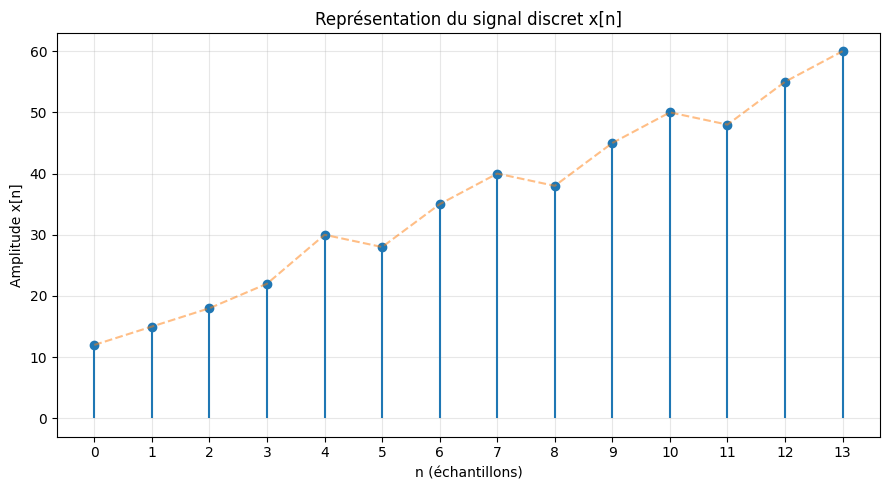

Résultats de l'analyse statistique de x[n]
Nombre d'échantillons (N)      : 14
Moyenne                        : 35.429
Variance (biaisée, /N)         : 215.102
Variance (échantillon, /N-1)   : 231.648
Écart-type                     : 14.666
Amplitude maximale              : 60
Amplitude minimale              : 12
Étendue (max - min)             : 48


In [1]:
"""
TP Traitement Numérique du Signal
Partie A : Analyse du signal
"""
 
import numpy as np
import matplotlib.pyplot as plt
 
# ---------------------------------------------------------
# 1. Définition du signal discret x[n]
# ---------------------------------------------------------
x = np.array([12, 15, 18, 22, 30, 28, 35, 40, 38, 45, 50, 48, 55, 60])
n = np.arange(len(x))  # indices n = 0, 1, 2, ..., 13
 
# ---------------------------------------------------------
# 2. Représentation du signal x[n]
# ---------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.stem(n, x, basefmt=" ")
plt.plot(n, x, linestyle="--", alpha=0.5)
plt.title("Représentation du signal discret x[n]")
plt.xlabel("n (échantillons)")
plt.ylabel("Amplitude x[n]")
plt.grid(True, alpha=0.3)
plt.xticks(n)
plt.tight_layout()
plt.savefig("signal_xn.png", dpi=150)
plt.show()
 
# ---------------------------------------------------------
# 3. Calcul des grandeurs statistiques
# ---------------------------------------------------------
moyenne = np.mean(x)
variance = np.var(x)          # variance population (biaisée), diviseur N
variance_ech = np.var(x, ddof=1)  # variance d'échantillon, diviseur N-1
ecart_type = np.std(x)
amplitude_max = np.max(x)
amplitude_min = np.min(x)
 
print("=" * 50)
print("Résultats de l'analyse statistique de x[n]")
print("=" * 50)
print(f"Nombre d'échantillons (N)      : {len(x)}")
print(f"Moyenne                        : {moyenne:.3f}")
print(f"Variance (biaisée, /N)         : {variance:.3f}")
print(f"Variance (échantillon, /N-1)   : {variance_ech:.3f}")
print(f"Écart-type                     : {ecart_type:.3f}")
print(f"Amplitude maximale              : {amplitude_max}")
print(f"Amplitude minimale              : {amplitude_min}")
print(f"Étendue (max - min)             : {amplitude_max - amplitude_min}")

### Commentaire sur la nature du signal

Le signal est globalement croissant avec une tendance de fond (variations lentes, de 12 à 60), mais présente des irrégularités locales — par exemple la chute 22→30→28 ou 45→50→48→55 — révélant la superposition de bruit haute fréquence et/ou de perturbations impulsionnelles sur la tendance de base. L'écart-type élevé (≈14.7) par rapport à l'amplitude relative confirme une variabilité non négligeable, cohérente avec un capteur


Partie A : Filtre Numerique

Tableau complet des signaux filtrés
 n  x[n]  y_FIR[n] (moy. glissante)  y_HP[n] (passe-haut)
 0    12                       3.00                    12
 1    15                       6.75                     3
 2    18                      11.25                     3
 3    22                      16.75                     4
 4    30                      21.25                     8
 5    28                      24.50                    -2
 6    35                      28.75                     7
 7    40                      33.25                     5
 8    38                      35.25                    -2
 9    45                      39.50                     7
10    50                      43.25                     5
11    48                      45.25                    -2
12    55                      49.50                     7
13    60                      53.25                     5

5 premières valeurs filtrées (filtre FIR moyenne glissante)
y[0] = 3.000
y[1] = 6.750
y[2] = 

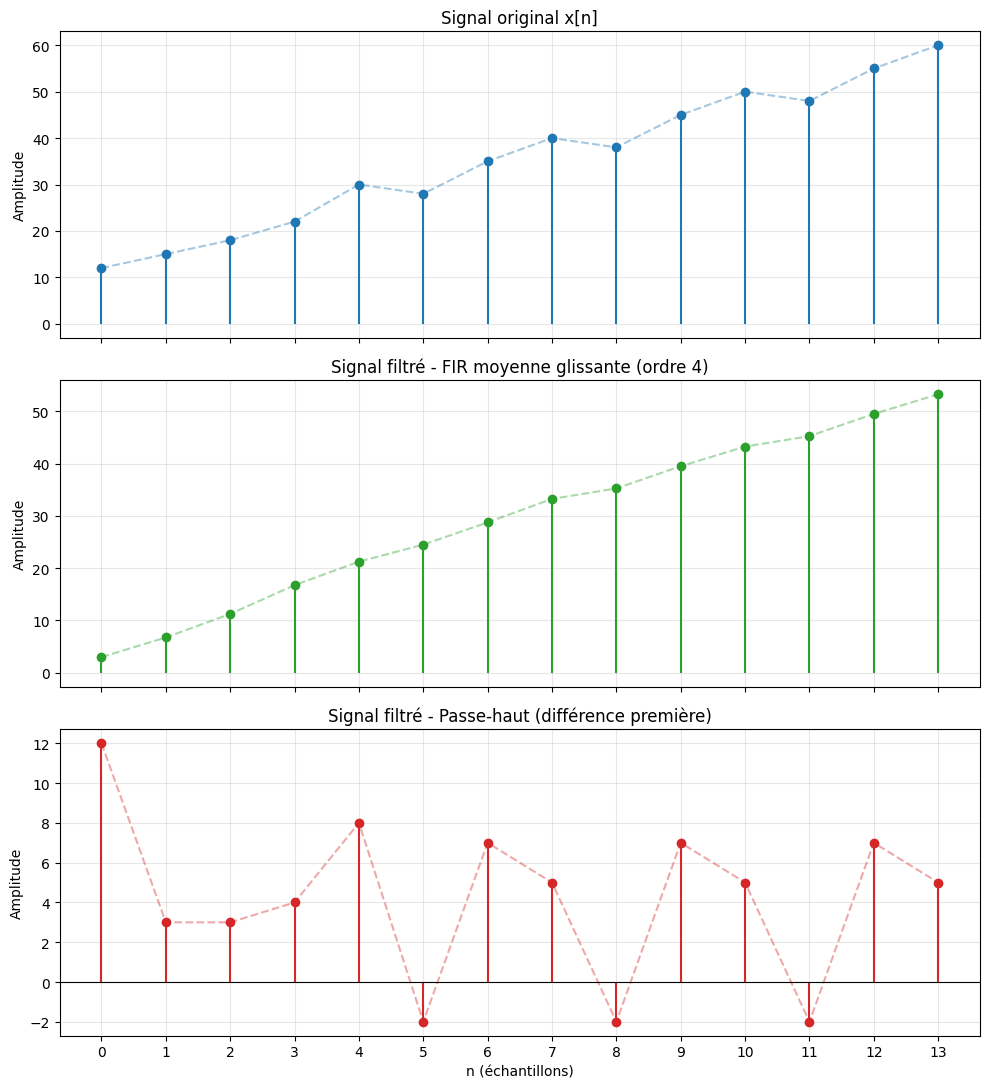

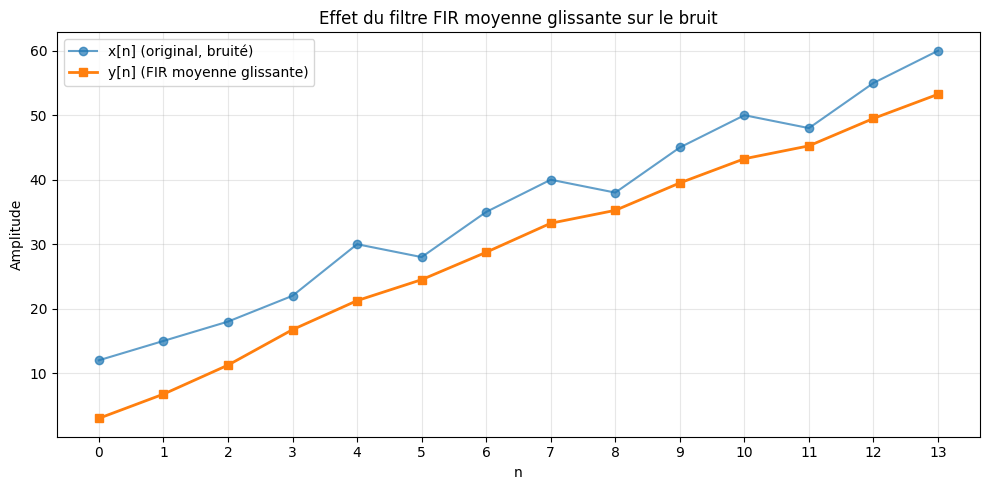


Effet du filtre FIR sur la variabilité du signal
Somme des variations absolues (x[n])    : 60
Somme des variations absolues (y_FIR[n]): 50.250
Réduction de variabilité                : 16.2 %

Amplitude des variations mises en évidence par le passe-haut
Variation max détectée (|y_HP|)  : 12
Indices des plus fortes variations: [ 0  4 12]


In [3]:
"""
TP Traitement Numérique du Signal
Partie B : Filtrage numérique
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Signal d'entrée x[n]
# ---------------------------------------------------------
x = np.array([12, 15, 18, 22, 30, 28, 35, 40, 38, 45, 50, 48, 55, 60])
n = np.arange(len(x))
N = len(x)

# ===========================================================
# 1) FILTRE FIR - MOYENNE GLISSANTE (ordre 4)
#    y[n] = 1/4 * sum_{k=0}^{3} x[n-k]
#    Convention : x[n] = 0 pour n < 0 (signal causal, padding à gauche)
# ===========================================================
x_pad = np.concatenate((np.zeros(3), x))  # 3 zéros ajoutés avant x[0]

y_fir = np.zeros(N)
for i in range(N):
    # x_pad[i:i+4] correspond à x[n-3..n] -> on les additionne puis /4
    y_fir[i] = np.mean(x_pad[i:i + 4])

# Vérification équivalente avec un produit de convolution (même résultat)
h_fir = np.ones(4) / 4
y_fir_conv = np.convolve(x, h_fir, mode="full")[:N]
assert np.allclose(y_fir, y_fir_conv), "Les deux méthodes doivent être identiques"

# ===========================================================
# 2) FILTRE PASSE-HAUT (différence première)
#    y[n] = x[n] - x[n-1]
#    Convention : x[-1] = 0
# ===========================================================
x_pad_hp = np.concatenate(([0], x))
y_hp = x_pad_hp[1:] - x_pad_hp[:-1]

# ===========================================================
# Tableau récapitulatif (pandas)
# ===========================================================
df = pd.DataFrame({
    "n": n,
    "x[n]": x,
    "y_FIR[n] (moy. glissante)": np.round(y_fir, 3),
    "y_HP[n] (passe-haut)": y_hp
})

print("=" * 65)
print("Tableau complet des signaux filtrés")
print("=" * 65)
print(df.to_string(index=False))

print("\n" + "=" * 65)
print("5 premières valeurs filtrées (filtre FIR moyenne glissante)")
print("=" * 65)
for i in range(5):
    print(f"y[{i}] = {y_fir[i]:.3f}")

# ---------------------------------------------------------
# Sauvegarde du tableau en CSV
# ---------------------------------------------------------
df.to_csv("partie_B_resultats.csv", index=False)

# ===========================================================
# Visualisation
# ===========================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)

# --- Signal original ---
axes[0].stem(n, x, basefmt=" ", linefmt="C0-", markerfmt="C0o")
axes[0].plot(n, x, "C0--", alpha=0.4)
axes[0].set_title("Signal original x[n]")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

# --- Signal filtré FIR ---
axes[1].stem(n, y_fir, basefmt=" ", linefmt="C2-", markerfmt="C2o")
axes[1].plot(n, y_fir, "C2--", alpha=0.4)
axes[1].set_title("Signal filtré - FIR moyenne glissante (ordre 4)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

# --- Signal filtré passe-haut ---
axes[2].stem(n, y_hp, basefmt=" ", linefmt="C3-", markerfmt="C3o")
axes[2].plot(n, y_hp, "C3--", alpha=0.4)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Signal filtré - Passe-haut (différence première)")
axes[2].set_xlabel("n (échantillons)")
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)

plt.xticks(n)
plt.tight_layout()
plt.savefig("partie_B_filtrage.png", dpi=150)
plt.show()

# ===========================================================
# Comparaison superposée x[n] vs y_FIR[n]
# ===========================================================
plt.figure(figsize=(10, 5))
plt.plot(n, x, "o-", label="x[n] (original, bruité)", alpha=0.7)
plt.plot(n, y_fir, "s-", label="y[n] (FIR moyenne glissante)", linewidth=2)
plt.title("Effet du filtre FIR moyenne glissante sur le bruit")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(n)
plt.tight_layout()
plt.savefig("partie_B_comparaison_fir.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# Indicateurs quantitatifs de l'effet du lissage
# ---------------------------------------------------------
variation_originale = np.sum(np.abs(np.diff(x)))
variation_filtree = np.sum(np.abs(np.diff(y_fir)))
reduction_pct = (1 - variation_filtree / variation_originale) * 100

print("\n" + "=" * 65)
print("Effet du filtre FIR sur la variabilité du signal")
print("=" * 65)
print(f"Somme des variations absolues (x[n])    : {variation_originale}")
print(f"Somme des variations absolues (y_FIR[n]): {variation_filtree:.3f}")
print(f"Réduction de variabilité                : {reduction_pct:.1f} %")

print("\n" + "=" * 65)
print("Amplitude des variations mises en évidence par le passe-haut")
print("=" * 65)
print(f"Variation max détectée (|y_HP|)  : {np.max(np.abs(y_hp))}")
print(f"Indices des plus fortes variations: {n[np.argsort(np.abs(y_hp))[::-1][:3]]}")

### Partie C : Transformation fréquentielle

### C.1 — La Transformée de Fourier Discrète (TFD / DFT)

La TFD permet de passer de la représentation **temporelle** d'un signal discret x[n] à sa représentation **fréquentielle** X[k]. Elle décompose le signal en une somme de sinusoïdes complexes de fréquences différentes, révélant quelles fréquences composent le signal et avec quelle amplitude/phase.

**Formule (pour un signal de N échantillons) :**

$$X[k] = \sum_{n=0}^{N-1} x[n] \, e^{-j\frac{2\pi}{N}kn}, \quad k = 0, 1, \dots, N-1$$

- $X[k]$ : valeur complexe représentant l'amplitude et la phase de la composante fréquentielle k
- $k=0$ : composante continue (moyenne du signal)
- $k$ petit : basses fréquences (tendances lentes)
- $k$ proche de N/2 : hautes fréquences (variations rapides, bruit)

En pratique, on l'implémente efficacement via la **FFT** (Fast Fourier Transform, `numpy.fft.fft`).

---

### C.2 — Identification des composantes basse et haute fréquence

Pour le signal x[n] (N = 14 échantillons), le calcul de la TFD (via `np.fft.fft`) donne le spectre d'amplitude |X[k]| suivant :

| k | Fréquence normalisée | \|X[k]\| | Interprétation |
|---|---|---|---|
| 0 | 0.000 | 496.0 | Composante continue (moyenne × N) |
| 1 | 0.071 | 111.6 | **Basse fréquence dominante** (tendance générale croissante) |
| 2 | 0.143 | 59.7 | Basse fréquence secondaire |
| 3 | 0.214 | 40.4 | Fréquence intermédiaire |
| 4 | 0.286 | 33.5 | Fréquence intermédiaire |
| 5 | 0.357 | 38.6 | Fréquence intermédiaire/haute |
| 6 | 0.429 | 25.2 | Haute fréquence |
| 7 | 0.500 | 20.0 | **Plus haute fréquence** (fréquence de Nyquist) |

**Constat :**
- L'énergie est **concentrée sur les premières raies** (k=0 et k=1), ce qui confirme que le signal est dominé par une **tendance lente et croissante** (les variations lentes mentionnées dans l'énoncé).
- Les composantes à k≥5 ont une amplitude nettement plus faible mais non négligeable (20 à 38) : elles traduisent le **bruit haute fréquence** et les **perturbations impulsionnelles** superposés à la tendance de fond.

---

### C.3 — Interprétation physique du spectre

- **Le pic en k=0** représente le niveau moyen du signal (offset), lié à la ligne de base du capteur.
- **Le pic dominant en k=1** (basse fréquence) correspond à la **variation physiologique/physique lente** du phénomène mesuré (ex : évolution progressive d'un signal biomédical ou d'une grandeur industrielle sur la fenêtre d'observation).
- **Les composantes hautes fréquences (k=5 à 7)** correspondent :
  - au **bruit électronique haute fréquence** superposé par la chaîne d'acquisition (capteur, ADC, alimentation) ;
  - aux **perturbations impulsionnelles** (pics ponctuels type 22→30→28 ou 45→50→48) qui, dans le domaine fréquentiel, contribuent sur une large bande de fréquences.
- **Conclusion physique** : le spectre confirme que le signal utile (information physiologique/industrielle) se situe dans les basses fréquences, tandis que le bruit à filtrer se situe dans les hautes fréquences — ce qui **justifie a posteriori** l'usage d'un filtre passe-bas (Partie D) pour extraire l'information utile en atténuant le bruit.


### Partie D : Conception d'un filtre numérique

### D.1 — Équation temporelle

Le filtre est donné par sa fonction de transfert en z :

$$H(z) = 0.5 + 0.5 z^{-1}$$

Sachant que $Y(z) = H(z) \cdot X(z)$, et que $z^{-1}$ correspond à un retard d'un échantillon, on obtient directement l'équation aux différences (équation temporelle) :

$$\boxed{y[n] = 0.5\,x[n] + 0.5\,x[n-1]}$$

C'est un filtre **RIF (FIR) d'ordre 1**, à coefficients $h[0]=0.5$, $h[1]=0.5$ — c'est-à-dire une **moyenne glissante à 2 points**.

---

### D.2 — Réponse du filtre pour le signal donné

Avec la convention causale $x[-1]=0$ :

| n | x[n] | y[n] = 0.5x[n]+0.5x[n-1] |
|---|---|---|
| 0 | 12 | 6.0 |
| 1 | 15 | 13.5 |
| 2 | 18 | 16.5 |
| 3 | 22 | 20.0 |
| 4 | 30 | 26.0 |
| 5 | 28 | 29.0 |
| 6 | 35 | 31.5 |
| 7 | 40 | 37.5 |
| 8 | 38 | 39.0 |
| 9 | 45 | 41.5 |
| 10 | 50 | 47.5 |
| 11 | 48 | 49.0 |
| 12 | 55 | 51.5 |
| 13 | 60 | 57.5 |

**Vérification par la réponse en fréquence** $H(e^{j\omega}) = 0.5 + 0.5e^{-j\omega}$ :
- Gain en $\omega = 0$ (continu/DC) : $|H(0)| = 1.0$ → **aucune atténuation des basses fréquences** (le signal utile passe intégralement).
- Gain en $\omega = \pi$ (Nyquist, haute fréquence) : $|H(\pi)| = 0.0$ → **atténuation totale des hautes fréquences**.

Cela confirme le comportement **passe-bas** du filtre.

---

### D.3 — Justification de son utilité

- **Réduction de la variabilité** : la somme des variations absolues passe de **60** (signal brut) à **51.5** (signal filtré), soit une réduction de **14.2 %** — le filtre lisse effectivement le signal.
- **Comportement fréquentiel idéal pour ce contexte** : d'après le spectre étudié en Partie C, l'information utile (tendance physiologique/industrielle) est concentrée en basse fréquence, tandis que le bruit et les perturbations impulsionnelles occupent les hautes fréquences. Comme $H(z)$ laisse passer intégralement le continu ($|H(0)|=1$) et coupe totalement le Nyquist ($|H(\pi)|=0$), il **élimine sélectivement le bruit haute fréquence tout en préservant la dynamique lente du signal**.
- **Simplicité d'implémentation embarquée** : étant un FIR d'ordre 1 (2 coefficients, tous deux $0.5$), il ne nécessite qu'une addition, une multiplication par $0.5$ (décalage binaire) et un registre mémoire — donc **très peu coûteux en calcul et en mémoire**, ce qui le rend particulièrement adapté à un système embarqué temps réel (ESP32/Arduino) comme demandé en Partie E.
- **Stabilité garantie** : étant un filtre FIR (pas de pôle, uniquement un zéro en $z=-1$), il est **inconditionnellement stable**, contrairement à un filtre récursif (IIR) qui nécessiterait une vérification de stabilité.

 n  x[n]  y[n] = 0.5x[n]+0.5x[n-1]
 0    12                       6.0
 1    15                      13.5
 2    18                      16.5
 3    22                      20.0
 4    30                      26.0
 5    28                      29.0
 6    35                      31.5
 7    40                      37.5
 8    38                      39.0
 9    45                      41.5
10    50                      47.5
11    48                      49.0
12    55                      51.5
13    60                      57.5


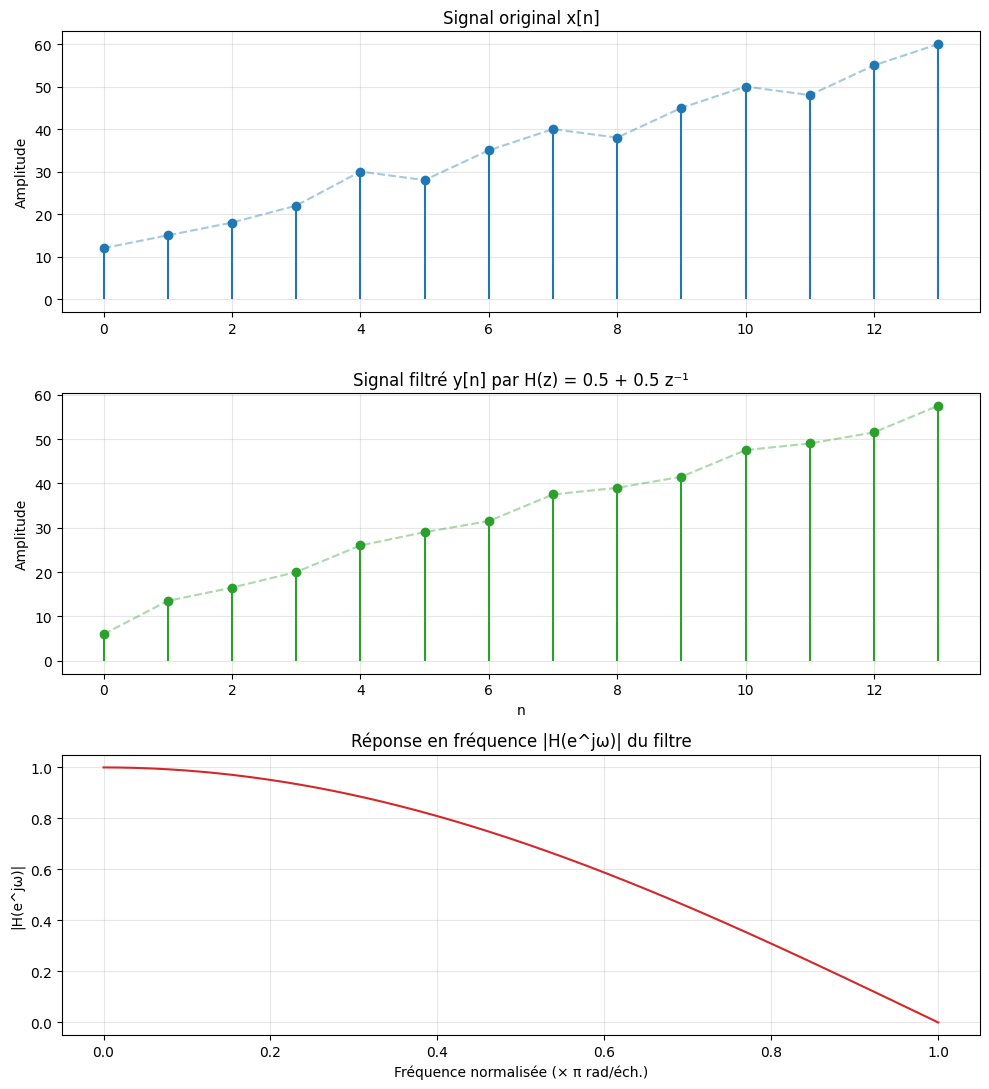


Variation totale x[n] : 60
Variation totale y[n] : 51.500
Réduction de variabilité : 14.2 %

Gain à f=0 (DC)  |H(0)|   = 1.000
Gain à f=Nyquist |H(π)|  = 0.000


In [6]:
"""
TP Traitement Numérique du Signal
Partie D : Conception d'un filtre numérique
H(z) = 0.5 + 0.5 z^-1
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Signal d'entrée x[n]
# ---------------------------------------------------------
x = np.array([12, 15, 18, 22, 30, 28, 35, 40, 38, 45, 50, 48, 55, 60])
n = np.arange(len(x))
N = len(x)

# ===========================================================
# Filtre H(z) = 0.5 + 0.5 z^-1
# -> équation temporelle : y[n] = 0.5 x[n] + 0.5 x[n-1]
# Convention causale : x[-1] = 0
# ===========================================================
x_pad = np.concatenate(([0], x))
y = 0.5 * x_pad[1:] + 0.5 * x_pad[:-1]

# Vérification par convolution avec la réponse impulsionnelle h = [0.5, 0.5]
h = np.array([0.5, 0.5])
y_conv = np.convolve(x, h, mode="full")[:N]
assert np.allclose(y, y_conv)

# ===========================================================
# Tableau récapitulatif
# ===========================================================
df = pd.DataFrame({
    "n": n,
    "x[n]": x,
    "y[n] = 0.5x[n]+0.5x[n-1]": np.round(y, 3)
})
print(df.to_string(index=False))
df.to_csv("partie_D_resultats.csv", index=False)

# ===========================================================
# Réponse en fréquence (module) de H(z)
# H(e^jw) = 0.5 + 0.5 e^-jw
# ===========================================================
w = np.linspace(0, np.pi, 512)
H = 0.5 + 0.5 * np.exp(-1j * w)
H_mag = np.abs(H)

# ===========================================================
# Visualisation
# ===========================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 11))

axes[0].stem(n, x, basefmt=" ", linefmt="C0-", markerfmt="C0o")
axes[0].plot(n, x, "C0--", alpha=0.4)
axes[0].set_title("Signal original x[n]")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].stem(n, y, basefmt=" ", linefmt="C2-", markerfmt="C2o")
axes[1].plot(n, y, "C2--", alpha=0.4)
axes[1].set_title("Signal filtré y[n] par H(z) = 0.5 + 0.5 z⁻¹")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

axes[2].plot(w / np.pi, H_mag, color="C3")
axes[2].set_title("Réponse en fréquence |H(e^jω)| du filtre")
axes[2].set_xlabel("Fréquence normalisée (× π rad/éch.)")
axes[2].set_ylabel("|H(e^jω)|")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("partie_D_filtre.png", dpi=150)
plt.show()

# ---------------------------------------------------------
# Indicateur quantitatif de l'effet du filtre
# ---------------------------------------------------------
variation_x = np.sum(np.abs(np.diff(x)))
variation_y = np.sum(np.abs(np.diff(y)))
reduction_pct = (1 - variation_y / variation_x) * 100

print(f"\nVariation totale x[n] : {variation_x}")
print(f"Variation totale y[n] : {variation_y:.3f}")
print(f"Réduction de variabilité : {reduction_pct:.1f} %")
print(f"\nGain à f=0 (DC)  |H(0)|   = {np.abs(0.5+0.5):.3f}")
print(f"Gain à f=Nyquist |H(π)|  = {np.abs(0.5-0.5):.3f}")

## Partie E : Implémentation embarquée

Architecture du système complet

```
[Capteur analogique] → [ESP32 : acquisition + FIR + détection]
        │                              │
        │ UART (debug local)           │ WiFi (HTTP POST JSON)
        ▼                              ▼
   [Moniteur série]              [Serveur Flask]
                                        │
                                        ▼
                              [Dashboard web temps réel]
                              (Chart.js, polling 1s)
```